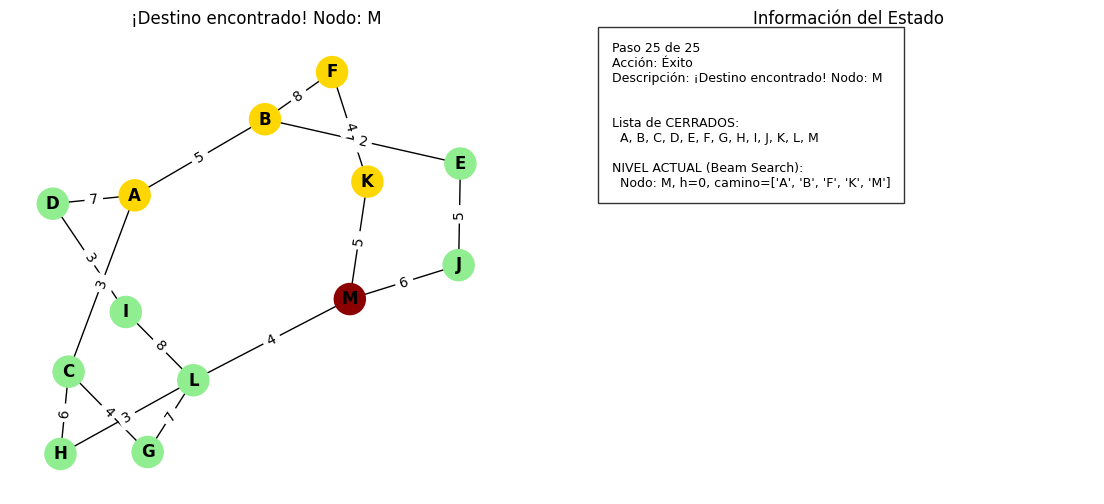

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from heapq import heappush, heappop

# Definir colores para la visualización
COLORES = {
    "no_visitado": "lightgray",
    "actual": "tomato",
    "abierto": "lightblue",
    "cerrado": "lightgreen",
    "camino": "gold",
    "destino": "darkred",
}


# Clase para visualizar algoritmos
class VisualizadorAlgoritmos:
    def __init__(self, grafo, heuristicas=None):
        self.grafo = grafo
        self.heuristicas = heuristicas if heuristicas else {}
        # Crear grafo de networkx
        self.G = nx.Graph()
        for origen, destinos in grafo.items():
            for destino, peso in destinos:
                self.G.add_edge(origen, destino, weight=peso)

        # Calcular posiciones fijas para los nodos (esto es importante para la visualización)
        self.pos = nx.spring_layout(self.G, seed=42)

    def dibujar_grafo_basico(self):
        """Dibuja el grafo básico con sus pesos"""
        plt.figure(figsize=(10, 8))
        nx.draw(
            self.G,
            self.pos,
            with_labels=True,
            node_color="lightgray",
            node_size=500,
            font_weight="bold",
        )
        edge_labels = nx.get_edge_attributes(self.G, "weight")
        nx.draw_networkx_edge_labels(self.G, self.pos, edge_labels=edge_labels)
        plt.title("Grafo original")
        plt.axis("off")
        plt.tight_layout()

    def mostrar_heuristicas(self, destino):
        """Muestra las heurísticas del grafo hacia un destino específico"""
        if not self.heuristicas:
            print("No hay heurísticas definidas.")
            return

        plt.figure(figsize=(10, 8))
        # Dibujar el grafo
        nx.draw(
            self.G,
            self.pos,
            with_labels=True,
            node_color="lightgray",
            node_size=500,
            font_weight="bold",
        )

        # Dibujar etiquetas de heurísticas
        for nodo, h in self.heuristicas.items():
            x, y = self.pos[nodo]
            plt.text(
                x,
                y - 0.1,
                f"h={h}",
                horizontalalignment="center",
                bbox=dict(facecolor="white", alpha=0.7),
            )

        # Destacar el nodo destino
        nx.draw_networkx_nodes(
            self.G,
            self.pos,
            nodelist=[destino],
            node_color=COLORES["destino"],
            node_size=700,
        )

        plt.title(f"Heurísticas hacia {destino}")
        plt.axis("off")
        plt.tight_layout()

    def crear_animacion(self, algoritmo, inicio, destino, **kwargs):
        """Crea una animación para visualizar el algoritmo paso a paso"""
        # Ejecutar el algoritmo y obtener la historia
        historial = algoritmo(self.grafo, inicio, destino, self.heuristicas, **kwargs)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        def update(frame):
            estado = historial[frame]

            # Limpiar ejes
            ax1.clear()
            ax2.clear()

            # Dibujar el grafo en el estado actual
            self.dibujar_estado_grafo(ax1, estado)

            # Mostrar información de estado en texto
            self.mostrar_info_estado(ax2, estado, frame, len(historial))

        ani = FuncAnimation(
            fig, update, frames=len(historial), interval=1500, repeat=True
        )

        return HTML(ani.to_jshtml())

    def dibujar_estado_grafo(self, ax, estado):
        """Dibuja el grafo en un estado específico"""
        # Definir colores para los nodos según su estado
        colores_nodos = {}

        # Establecer colores por defecto
        for nodo in self.G.nodes():
            colores_nodos[nodo] = COLORES["no_visitado"]

        # Nodos cerrados
        if "cerrados" in estado:
            for nodo in estado["cerrados"]:
                colores_nodos[nodo] = COLORES["cerrado"]

        # Nodos abiertos
        if "abiertos" in estado:
            for nodo, g, f, _ in estado["abiertos"]:
                colores_nodos[nodo] = COLORES["abierto"]

        # Nodo actual
        if "actual" in estado and estado["actual"]:
            colores_nodos[estado["actual"]] = COLORES["actual"]

        # Nodos en el camino (si existe)
        if "camino" in estado and estado["camino"]:
            for nodo in estado["camino"]:
                colores_nodos[nodo] = COLORES["camino"]

        # Nodo destino (si se ha llegado)
        if "destino_alcanzado" in estado and estado["destino_alcanzado"]:
            colores_nodos[estado["destino"]] = COLORES["destino"]

        # Dibujar nodos con colores
        node_colors = [colores_nodos[nodo] for nodo in self.G.nodes()]
        nx.draw(
            self.G,
            self.pos,
            ax=ax,
            with_labels=True,
            node_color=node_colors,
            node_size=500,
            font_weight="bold",
        )

        # Dibujar pesos de aristas
        edge_labels = nx.get_edge_attributes(self.G, "weight")
        nx.draw_networkx_edge_labels(self.G, self.pos, edge_labels=edge_labels, ax=ax)

        # Añadir información de f, g, h para nodos en abiertos
        if "abiertos" in estado:
            for nodo, g, f, _ in estado["abiertos"]:
                x, y = self.pos[nodo]
                h = f - g
                # Posicionar el texto para no tapar el nodo
                ax.text(
                    x,
                    y - 0.1,
                    f"f={f}\n(g={g},h={h})",
                    horizontalalignment="center",
                    color="black",
                    bbox=dict(facecolor="white", alpha=0.7, pad=0.3, boxstyle="round"),
                )

        ax.set_title(estado["descripcion"])
        ax.axis("off")

    def mostrar_info_estado(self, ax, estado, frame, total_frames):
        """Muestra información del estado en formato texto"""
        texto = [
            f"Paso {frame + 1} de {total_frames}",
            f"Acción: {estado['accion']}",
            f"Descripción: {estado['descripcion']}",
            "",
        ]

        # Detalles específicos según el tipo de algoritmo
        if "abiertos" in estado:
            texto.append("Lista de ABIERTOS:")
            for nodo, g, f, camino in estado["abiertos"]:
                texto.append(f"  Nodo: {nodo}, g={g}, f={f}, camino={camino}")

        if "cerrados" in estado:
            texto.append("\nLista de CERRADOS:")
            texto.append(f"  {', '.join(sorted(estado['cerrados']))}")

        if "nivel_actual" in estado:
            texto.append("\nNIVEL ACTUAL (Beam Search):")
            for nodo, camino, h in estado["nivel_actual"]:
                texto.append(f"  Nodo: {nodo}, h={h}, camino={camino}")

        if "candidatos" in estado:
            texto.append("\nCANDIDATOS:")
            for info in estado["candidatos"]:
                if len(info) == 3:  # beam search
                    nodo, camino, h = info
                    texto.append(f"  Nodo: {nodo}, h={h}, camino={camino}")

        # Mostrar el texto en el panel derecho
        texto_completo = "\n".join(texto)
        ax.text(
            0.02,
            0.98,
            texto_completo,
            verticalalignment="top",
            horizontalalignment="left",
            transform=ax.transAxes,
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.8, pad=10),
        )

        ax.set_title("Información del Estado")
        ax.axis("off")


# Implementaciones de algoritmos que devuelven historial detallado


def busqueda_anchura(grafo, inicio, destino, heuristicas=None, **kwargs):
    """
    Búsqueda en anchura (BFS) con registro detallado de estados
    """
    historial = []

    # Cola FIFO
    abiertos = [[inicio, 0, 0, [inicio]]]  # [nodo, g, f, camino]
    cerrados = set()

    # Estado inicial
    historial.append(
        {
            "descripcion": "Estado inicial",
            "accion": "Inicialización",
            "actual": None,
            "abiertos": abiertos.copy(),
            "cerrados": set(),
            "destino": destino,
            "destino_alcanzado": False,
        }
    )

    while abiertos:
        # Extraer el primer nodo de la cola (FIFO)
        nodo, g, f, camino = abiertos.pop(0)

        historial.append(
            {
                "descripcion": f"Explorando nodo: {nodo}",
                "accion": "Extraer de ABIERTOS",
                "actual": nodo,
                "abiertos": abiertos.copy(),
                "cerrados": cerrados.copy(),
                "destino": destino,
                "destino_alcanzado": False,
            }
        )

        # Verificar si es el destino
        if nodo == destino:
            historial.append(
                {
                    "descripcion": f"¡Destino encontrado! Nodo: {nodo}",
                    "accion": "Éxito",
                    "actual": nodo,
                    "abiertos": abiertos.copy(),
                    "cerrados": cerrados.copy(),
                    "camino": camino,
                    "destino": destino,
                    "destino_alcanzado": True,
                }
            )
            return historial

        # Marcar como explorado
        cerrados.add(nodo)

        # Explorar vecinos
        for vecino, peso in grafo[nodo]:
            if vecino not in cerrados and not any(vecino == n[0] for n in abiertos):
                nuevo_g = g + peso
                nuevo_f = nuevo_g  # En BFS, f = g (no hay heurística)
                nuevo_camino = camino + [vecino]
                abiertos.append([vecino, nuevo_g, nuevo_f, nuevo_camino])

                historial.append(
                    {
                        "descripcion": f"Añadiendo vecino {vecino} de {nodo} a ABIERTOS",
                        "accion": "Expandir",
                        "actual": nodo,
                        "abiertos": abiertos.copy(),
                        "cerrados": cerrados.copy(),
                        "destino": destino,
                        "destino_alcanzado": False,
                    }
                )

    # No se encontró camino
    historial.append(
        {
            "descripcion": "No se encontró camino al destino",
            "accion": "Fracaso",
            "actual": None,
            "abiertos": [],
            "cerrados": cerrados.copy(),
            "destino": destino,
            "destino_alcanzado": False,
        }
    )

    return historial


def costo_uniforme(grafo, inicio, destino, heuristicas=None, **kwargs):
    """
    Búsqueda de costo uniforme con registro detallado de estados
    """
    historial = []

    # Cola de prioridad por costo g
    abiertos = [[inicio, 0, 0, [inicio]]]  # [nodo, g, f, camino]
    cerrados = set()

    # Estado inicial
    historial.append(
        {
            "descripcion": "Estado inicial",
            "accion": "Inicialización",
            "actual": None,
            "abiertos": abiertos.copy(),
            "cerrados": set(),
            "destino": destino,
            "destino_alcanzado": False,
        }
    )

    while abiertos:
        # Ordenar por costo g
        abiertos.sort(key=lambda x: x[1])

        # Extraer el nodo con menor costo g
        nodo, g, f, camino = abiertos.pop(0)

        historial.append(
            {
                "descripcion": f"Explorando nodo: {nodo} (g={g})",
                "accion": "Extraer de ABIERTOS",
                "actual": nodo,
                "abiertos": abiertos.copy(),
                "cerrados": cerrados.copy(),
                "destino": destino,
                "destino_alcanzado": False,
            }
        )

        # Verificar si es el destino
        if nodo == destino:
            historial.append(
                {
                    "descripcion": f"¡Destino encontrado! Nodo: {nodo} (costo={g})",
                    "accion": "Éxito",
                    "actual": nodo,
                    "abiertos": abiertos.copy(),
                    "cerrados": cerrados.copy(),
                    "camino": camino,
                    "destino": destino,
                    "destino_alcanzado": True,
                }
            )
            return historial

        # Si ya está explorado, continuar
        if nodo in cerrados:
            continue

        # Marcar como explorado
        cerrados.add(nodo)

        # Explorar vecinos
        for vecino, peso in grafo[nodo]:
            nuevo_g = g + peso
            nuevo_f = nuevo_g  # En costo uniforme, f = g
            nuevo_camino = camino + [vecino]

            # Verificar si el vecino ya está en abiertos
            vecino_en_abiertos = False
            for i, (v, v_g, v_f, v_camino) in enumerate(abiertos):
                if v == vecino:
                    vecino_en_abiertos = True
                    # Si encontramos un mejor camino
                    if nuevo_g < v_g:
                        abiertos[i] = [vecino, nuevo_g, nuevo_f, nuevo_camino]
                        historial.append(
                            {
                                "descripcion": f"Actualizando vecino {vecino} de {nodo} con mejor camino (g={nuevo_g})",
                                "accion": "Actualizar",
                                "actual": nodo,
                                "abiertos": abiertos.copy(),
                                "cerrados": cerrados.copy(),
                                "destino": destino,
                                "destino_alcanzado": False,
                            }
                        )
                    break

            # Si no está en abiertos y no está explorado
            if not vecino_en_abiertos and vecino not in cerrados:
                abiertos.append([vecino, nuevo_g, nuevo_f, nuevo_camino])
                historial.append(
                    {
                        "descripcion": f"Añadiendo vecino {vecino} de {nodo} a ABIERTOS (g={nuevo_g})",
                        "accion": "Expandir",
                        "actual": nodo,
                        "abiertos": abiertos.copy(),
                        "cerrados": cerrados.copy(),
                        "destino": destino,
                        "destino_alcanzado": False,
                    }
                )

    # No se encontró camino
    historial.append(
        {
            "descripcion": "No se encontró camino al destino",
            "accion": "Fracaso",
            "actual": None,
            "abiertos": [],
            "cerrados": cerrados.copy(),
            "destino": destino,
            "destino_alcanzado": False,
        }
    )

    return historial


def a_estrella(grafo, inicio, destino, heuristicas, **kwargs):
    """
    Algoritmo A* con registro detallado de estados
    """
    if not heuristicas:
        raise ValueError("Se requieren heurísticas para el algoritmo A*")

    historial = []

    # Cola de prioridad por f = g + h
    abiertos = [[inicio, 0, heuristicas[inicio], [inicio]]]  # [nodo, g, f, camino]
    cerrados = set()

    # Estado inicial
    historial.append(
        {
            "descripcion": "Estado inicial",
            "accion": "Inicialización",
            "actual": None,
            "abiertos": abiertos.copy(),
            "cerrados": set(),
            "destino": destino,
            "destino_alcanzado": False,
        }
    )

    while abiertos:
        # Ordenar por valor f = g + h
        abiertos.sort(key=lambda x: x[2])

        # Extraer el nodo con menor f
        nodo, g, f, camino = abiertos.pop(0)

        historial.append(
            {
                "descripcion": f"Explorando nodo: {nodo} (g={g}, f={f})",
                "accion": "Extraer de ABIERTOS",
                "actual": nodo,
                "abiertos": abiertos.copy(),
                "cerrados": cerrados.copy(),
                "destino": destino,
                "destino_alcanzado": False,
            }
        )

        # Verificar si es el destino
        if nodo == destino:
            historial.append(
                {
                    "descripcion": f"¡Destino encontrado! Nodo: {nodo} (costo={g})",
                    "accion": "Éxito",
                    "actual": nodo,
                    "abiertos": abiertos.copy(),
                    "cerrados": cerrados.copy(),
                    "camino": camino,
                    "destino": destino,
                    "destino_alcanzado": True,
                }
            )
            return historial

        # Si ya está explorado, continuar
        if nodo in cerrados:
            continue

        # Marcar como explorado
        cerrados.add(nodo)

        # Explorar vecinos
        for vecino, peso in grafo[nodo]:
            nuevo_g = g + peso
            nuevo_f = nuevo_g + heuristicas[vecino]  # f = g + h
            nuevo_camino = camino + [vecino]

            # Verificar si el vecino ya está en abiertos
            vecino_en_abiertos = False
            for i, (v, v_g, v_f, v_camino) in enumerate(abiertos):
                if v == vecino:
                    vecino_en_abiertos = True
                    # Si encontramos un mejor camino
                    if nuevo_g < v_g:
                        abiertos[i] = [vecino, nuevo_g, nuevo_f, nuevo_camino]
                        historial.append(
                            {
                                "descripcion": f"Actualizando vecino {vecino} de {nodo} con mejor camino (g={nuevo_g}, f={nuevo_f})",
                                "accion": "Actualizar",
                                "actual": nodo,
                                "abiertos": abiertos.copy(),
                                "cerrados": cerrados.copy(),
                                "destino": destino,
                                "destino_alcanzado": False,
                            }
                        )
                    break

            # Si no está en abiertos y no está explorado
            if not vecino_en_abiertos and vecino not in cerrados:
                abiertos.append([vecino, nuevo_g, nuevo_f, nuevo_camino])
                historial.append(
                    {
                        "descripcion": f"Añadiendo vecino {vecino} de {nodo} a ABIERTOS (g={nuevo_g}, f={nuevo_f})",
                        "accion": "Expandir",
                        "actual": nodo,
                        "abiertos": abiertos.copy(),
                        "cerrados": cerrados.copy(),
                        "destino": destino,
                        "destino_alcanzado": False,
                    }
                )

    # No se encontró camino
    historial.append(
        {
            "descripcion": "No se encontró camino al destino",
            "accion": "Fracaso",
            "actual": None,
            "abiertos": [],
            "cerrados": cerrados.copy(),
            "destino": destino,
            "destino_alcanzado": False,
        }
    )

    return historial


def ascenso_colina(grafo, inicio, destino, heuristicas, **kwargs):
    """
    Algoritmo de Ascenso de Colina (Hill Climbing) con registro detallado de estados
    """
    if not heuristicas:
        raise ValueError(
            "Se requieren heurísticas para el algoritmo de Ascenso de Colina"
        )

    historial = []

    # Comenzar con el nodo inicial
    actual = inicio
    camino = [inicio]
    cerrados = set()

    # Estado inicial
    historial.append(
        {
            "descripcion": "Estado inicial",
            "accion": "Inicialización",
            "actual": actual,
            "abiertos": [],  # No hay lista de abiertos en este algoritmo
            "cerrados": cerrados.copy(),
            "destino": destino,
            "destino_alcanzado": False,
            "h_actual": heuristicas[actual],
        }
    )

    # Mientras no se llegue al destino
    while actual != destino:
        cerrados.add(actual)

        # Encontrar el mejor vecino (con menor heurística)
        mejor_vecino = None
        mejor_h = float("inf")

        vecinos_candidatos = []

        for vecino, peso in grafo[actual]:
            if vecino not in cerrados:
                h = heuristicas[vecino]
                vecinos_candidatos.append([vecino, h, camino + [vecino]])

                if h < mejor_h:
                    mejor_vecino = vecino
                    mejor_h = h

        # Registrar el estado actual
        historial.append(
            {
                "descripcion": f"Explorando nodo: {actual} (h={heuristicas[actual]})",
                "accion": "Explorar",
                "actual": actual,
                "abiertos": [],
                "cerrados": cerrados.copy(),
                "candidatos": vecinos_candidatos,
                "destino": destino,
                "destino_alcanzado": False,
                "h_actual": heuristicas[actual],
            }
        )

        # Si no hay vecinos o todos están explorados
        if mejor_vecino is None:
            historial.append(
                {
                    "descripcion": "Callejón sin salida - No hay vecinos disponibles",
                    "accion": "Fracaso",
                    "actual": actual,
                    "abiertos": [],
                    "cerrados": cerrados.copy(),
                    "destino": destino,
                    "destino_alcanzado": False,
                }
            )
            return historial

        # Si el mejor vecino no mejora la heurística, estamos en un mínimo local
        if mejor_h >= heuristicas[actual]:
            historial.append(
                {
                    "descripcion": f"Mínimo local alcanzado en {actual} (h={heuristicas[actual]})",
                    "accion": "Mínimo local",
                    "actual": actual,
                    "abiertos": [],
                    "cerrados": cerrados.copy(),
                    "destino": destino,
                    "destino_alcanzado": False,
                }
            )
            return historial

        # Moverse al mejor vecino
        actual = mejor_vecino
        camino.append(actual)

        # Registrar el movimiento
        historial.append(
            {
                "descripcion": f"Movimiento a mejor vecino: {actual} (h={heuristicas[actual]})",
                "accion": "Movimiento",
                "actual": actual,
                "abiertos": [],
                "cerrados": cerrados.copy(),
                "camino": camino.copy(),
                "destino": destino,
                "destino_alcanzado": actual == destino,
            }
        )

        # Si llegamos al destino
        if actual == destino:
            historial.append(
                {
                    "descripcion": f"¡Destino encontrado! Nodo: {actual}",
                    "accion": "Éxito",
                    "actual": actual,
                    "abiertos": [],
                    "cerrados": cerrados.copy(),
                    "camino": camino,
                    "destino": destino,
                    "destino_alcanzado": True,
                }
            )

    return historial


def beam_search(grafo, inicio, destino, heuristicas, beam_width=2, **kwargs):
    """
    Algoritmo de Beam Search con registro detallado de estados
    """
    if not heuristicas:
        raise ValueError("Se requieren heurísticas para el algoritmo Beam Search")

    historial = []

    # Nivel actual: [nodo, camino, heurística]
    nivel_actual = [[inicio, [inicio], heuristicas[inicio]]]
    visitados = set([inicio])

    # Estado inicial
    historial.append(
        {
            "descripcion": "Estado inicial",
            "accion": "Inicialización",
            "actual": None,
            "nivel_actual": nivel_actual.copy(),
            "cerrados": visitados.copy(),
            "destino": destino,
            "destino_alcanzado": False,
        }
    )

    while nivel_actual:
        siguiente_nivel = []

        for nodo, camino, _ in nivel_actual:
            historial.append(
                {
                    "descripcion": f"Explorando nodo: {nodo} (h={heuristicas[nodo]})",
                    "accion": "Explorar",
                    "actual": nodo,
                    "nivel_actual": nivel_actual.copy(),
                    "cerrados": visitados.copy(),
                    "destino": destino,
                    "destino_alcanzado": False,
                }
            )

            # Verificar si es el destino
            if nodo == destino:
                historial.append(
                    {
                        "descripcion": f"¡Destino encontrado! Nodo: {nodo}",
                        "accion": "Éxito",
                        "actual": nodo,
                        "nivel_actual": nivel_actual.copy(),
                        "cerrados": visitados.copy(),
                        "camino": camino,
                        "destino": destino,
                        "destino_alcanzado": True,
                    }
                )
                return historial

            # Explorar vecinos
            candidatos = []
            for vecino, _ in grafo[nodo]:
                if vecino not in visitados:
                    visitados.add(vecino)
                    nuevo_camino = camino + [vecino]
                    candidatos.append([vecino, nuevo_camino, heuristicas[vecino]])
                    siguiente_nivel.append([vecino, nuevo_camino, heuristicas[vecino]])

            if candidatos:
                historial.append(
                    {
                        "descripcion": f"Añadiendo candidatos desde {nodo}",
                        "accion": "Expandir",
                        "actual": nodo,
                        "nivel_actual": nivel_actual.copy(),
                        "candidatos": candidatos.copy(),
                        "cerrados": visitados.copy(),
                        "destino": destino,
                        "destino_alcanzado": False,
                    }
                )

        # Ordenar candidatos por heurística (menor primero)
        siguiente_nivel.sort(key=lambda x: x[2])

        # Seleccionar los mejores beam_width candidatos
        nivel_actual = siguiente_nivel[:beam_width]

        if siguiente_nivel:
            historial.append(
                {
                    "descripcion": f"Seleccionando los {beam_width} mejores candidatos para el siguiente nivel",
                    "accion": "Selección de beam",
                    "actual": None,
                    "candidatos": siguiente_nivel.copy(),
                    "nivel_actual": nivel_actual.copy(),
                    "cerrados": visitados.copy(),
                    "destino": destino,
                    "destino_alcanzado": False,
                }
            )

    # No se encontró camino
    historial.append(
        {
            "descripcion": "No se encontró camino al destino",
            "accion": "Fracaso",
            "actual": None,
            "nivel_actual": [],
            "cerrados": visitados.copy(),
            "destino": destino,
            "destino_alcanzado": False,
        }
    )

    return historial


# Ejemplo de uso
def crear_grafo_ejemplo():
    """Crea un grafo de ejemplo para mostrar los algoritmos"""
    grafo = {
        "A": [("B", 5), ("C", 3), ("D", 7)],
        "B": [("A", 5), ("E", 2), ("F", 8)],
        "C": [("A", 3), ("G", 4), ("H", 6)],
        "D": [("A", 7), ("I", 3)],
        "E": [("B", 2), ("J", 5)],
        "F": [("B", 8), ("K", 4)],
        "G": [("C", 4), ("L", 7)],
        "H": [("C", 6), ("L", 3)],
        "I": [("D", 3), ("L", 8)],
        "J": [("E", 5), ("M", 6)],
        "K": [("F", 4), ("M", 5)],
        "L": [("G", 7), ("H", 3), ("I", 8), ("M", 4)],
        "M": [("J", 6), ("K", 5), ("L", 4)],
    }

    # Heurísticas estimadas hacia el nodo 'M'
    heuristicas = {
        "A": 12,
        "B": 8,
        "C": 10,
        "D": 11,
        "E": 6,
        "F": 5,
        "G": 7,
        "H": 6,
        "I": 9,
        "J": 3,
        "K": 2,
        "L": 4,
        "M": 0,
    }

    return grafo, heuristicas


# Función para ejecutar la demo completa
def ejecutar_demo():
    """Ejecuta una demostración completa de los algoritmos de búsqueda"""
    grafo, heuristicas = crear_grafo_ejemplo()

    # Crear visualizador
    vis = VisualizadorAlgoritmos(grafo, heuristicas)

    # Mostrar grafo básico
    print("Mostrando grafo básico...")
    vis.dibujar_grafo_basico()

    # Mostrar heurísticas
    print("\nMostrando heurísticas hacia el nodo M...")
    vis.mostrar_heuristicas("M")

    # Ejecutar algoritmos
    inicio, destino = "A", "M"

    # BFS
    print(f"\nEjecutando Búsqueda en Anchura desde {inicio} hasta {destino}...")
    display(vis.crear_animacion(busqueda_anchura, inicio, destino))

    # DFS
    print(f"\nEjecutando Búsqueda en Profundidad desde {inicio} hasta {destino}...")
    display(vis.crear_animacion(busqueda_profundidad, inicio, destino))

    # Costo Uniforme
    print(f"\nEjecutando Búsqueda de Costo Uniforme desde {inicio} hasta {destino}...")
    display(vis.crear_animacion(costo_uniforme, inicio, destino))

    # A*
    print(f"\nEjecutando A* desde {inicio} hasta {destino}...")
    display(vis.crear_animacion(a_estrella, inicio, destino))

    # Ascenso de Colina
    print(f"\nEjecutando Ascenso de Colina desde {inicio} hasta {destino}...")
    display(vis.crear_animacion(ascenso_colina, inicio, destino))

    # Beam Search
    print(f"\nEjecutando Beam Search desde {inicio} hasta {destino} (beam_width=2)...")
    display(vis.crear_animacion(beam_search, inicio, destino, beam_width=2))


# Para ejecutar la demo en un notebook de Jupyter:
# ejecutar_demo()


def busqueda_profundidad(grafo, inicio, destino, heuristicas=None, **kwargs):
    """
    Búsqueda en profundidad (DFS) con registro detallado de estados
    """
    historial = []

    # Pila LIFO
    abiertos = [[inicio, 0, 0, [inicio]]]  # [nodo, g, f, camino]
    cerrados = set()

    # Estado inicial
    historial.append(
        {
            "descripcion": "Estado inicial",
            "accion": "Inicialización",
            "actual": None,
            "abiertos": abiertos.copy(),
            "cerrados": set(),
            "destino": destino,
            "destino_alcanzado": False,
        }
    )

    while abiertos:
        # Extraer el último nodo de la pila (LIFO)
        nodo, g, f, camino = abiertos.pop()

        historial.append(
            {
                "descripcion": f"Explorando nodo: {nodo}",
                "accion": "Extraer de ABIERTOS",
                "actual": nodo,
                "abiertos": abiertos.copy(),
                "cerrados": cerrados.copy(),
                "destino": destino,
                "destino_alcanzado": False,
            }
        )

        # Verificar si es el destino
        if nodo == destino:
            historial.append(
                {
                    "descripcion": f"¡Destino encontrado! Nodo: {nodo}",
                    "accion": "Éxito",
                    "actual": nodo,
                    "abiertos": abiertos.copy(),
                    "cerrados": cerrados.copy(),
                    "camino": camino,
                    "destino": destino,
                    "destino_alcanzado": True,
                }
            )
            return historial

        # Marcar como explorado
        cerrados.add(nodo)

        # Explorar vecinos (en orden inverso para mantener el orden original al usar LIFO)
        vecinos = [(vecino, peso) for vecino, peso in grafo[nodo]]
        vecinos.reverse()

        for vecino, peso in vecinos:
            if vecino not in cerrados and not any(vecino == n[0] for n in abiertos):
                nuevo_g = g + peso
                nuevo_f = nuevo_g  # En DFS, f = g (no hay heurística)
                nuevo_camino = camino + [vecino]
                abiertos.append([vecino, nuevo_g, nuevo_f, nuevo_camino])

                historial.append(
                    {
                        "descripcion": f"Añadiendo vecino {vecino} de {nodo} a ABIERTOS",
                        "accion": "Expandir",
                        "actual": nodo,
                        "abiertos": abiertos.copy(),
                        "cerrados": cerrados.copy(),
                        "destino": destino,
                        "destino_alcanzado": False,
                    }
                )


def main():
    """Application initializer."""
    grafo, heuristicas = crear_grafo_ejemplo()
    vis = VisualizadorAlgoritmos(grafo, heuristicas)

    # Visualizar solo Beam Search con ancho 3
    inicio, destino = "A", "M"
    display(vis.crear_animacion(beam_search, inicio, destino, beam_width=3))


if __name__ == "__main__":
    main()
